In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras as ks
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler


In [3]:
# Delayed neutron decay constants
lambda_C = np.array(
    [0.0129, 0.0312, 0.1342, 0.3439, 1.3903, 3.7265],
    dtype=np.float32
)

lambda_i = tf.constant(lambda_C, dtype=tf.float32)

# Delayed neutron fractions
beta_i = np.array(
    [11.2E-5, 74.15E-5, 63.9E-5,
     121.5E-5, 53.71E-5, 15.83E-5],
    dtype=np.float32
)

beta = np.sum(beta_i).astype(np.float32)

# Neutron generation time
ngen = np.float32(0.39E-6)

# Tensor versions
beta_i_tf = tf.constant(beta_i, dtype=tf.float32)
beta_tf = tf.constant(beta, dtype=tf.float32)
ngen_tf = tf.constant(ngen, dtype=tf.float32)

# Initial conditions
n0 = 1.0
c0_i = beta_i / (lambda_C * ngen) * n0

print('beta =', beta)
print('ngen =', ngen)


beta = 0.0034029
ngen = 3.9e-07


In [4]:
CSV_PATH = '/Users/gargisharma/downloads/data_prbs_0.1_Polarized (1).csv'

# Test read
test_df = pd.read_csv(CSV_PATH, nrows=5)
print(test_df.head())

   time       rho         p          C1          C2         C3         C4  \
0   0.0 -0.000001  0.999849  104.724376  235.173315  42.451450  45.803510   
1   0.2 -0.000001  0.999839  104.724335  235.173084  42.451252  45.803099   
2   0.4  0.000001  1.000132  104.724358  235.173214  42.451375  45.803384   
3   0.6 -0.000001  0.999842  104.724328  235.173047  42.451235  45.803098   
4   0.8 -0.000001  0.999832  104.724285  235.172808  42.451035  45.802693   

         C5        C6  
0  3.199900  0.235125  
1  3.199802  0.235115  
2  3.199921  0.235142  
3  3.199849  0.235126  
4  3.199758  0.235114  


In [5]:
CHUNK_SIZE = 50000

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
rho_scaler = MinMaxScaler()

print('Fitting scalers on chunks...')

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE):

    X_chunk = chunk[['time']].values.astype(np.float32)
    rho_chunk = chunk[['rho']].values.astype(np.float32)
    y_chunk = chunk[
        ['p','C1','C2','C3','C4','C5','C6']
    ].values.astype(np.float32)

    x_scaler.partial_fit(X_chunk)
    rho_scaler.partial_fit(rho_chunk)
    y_scaler.partial_fit(y_chunk)

print('Scalers fitted successfully.')

Fitting scalers on chunks...
Scalers fitted successfully.


In [6]:
first_chunk = next(
    pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE)
)

X = first_chunk[['time']].values.astype(np.float32)
rho = first_chunk[['rho']].values.astype(np.float32)
y = first_chunk[
    ['p','C1','C2','C3','C4','C5','C6']
].values.astype(np.float32)

# Scale
X_scaled = x_scaler.transform(X)
rho_scaled = rho_scaler.transform(rho)
y_scaled = y_scaler.transform(y)

# TensorFlow tensors
x_train_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
rho_train_tf = tf.convert_to_tensor(rho_scaled, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_scaled, dtype=tf.float32)

print(x_train_tf.shape)
print(y_train_tf.shape)
print(rho_train_tf.shape)

(50000, 1)
(50000, 7)
(50000, 1)


In [7]:
def mse_loss():

    @tf.function
    def loss(y_true, y_pred):

        # ==========================================
        # SAME LOGIC: predict on full training data
        # ==========================================

        with tf.GradientTape(persistent=True) as tape:

            tape.watch(x_train_tf)

            y_pred_all = model(x_train_tf)

            # Split outputs (same as your code)
            n_pred_tf  = y_pred_all[:, 0:1]

            c1_pred_tf = y_pred_all[:, 1:2]
            c2_pred_tf = y_pred_all[:, 2:3]
            c3_pred_tf = y_pred_all[:, 3:4]
            c4_pred_tf = y_pred_all[:, 4:5]
            c5_pred_tf = y_pred_all[:, 5:6]
            c6_pred_tf = y_pred_all[:, 6:7]

        # ==========================================
        # DERIVATIVES (same logic)
        # ==========================================

        dn_dt  = tape.gradient(n_pred_tf,  x_train_tf)

        dc1_dt = tape.gradient(c1_pred_tf, x_train_tf)
        dc2_dt = tape.gradient(c2_pred_tf, x_train_tf)
        dc3_dt = tape.gradient(c3_pred_tf, x_train_tf)
        dc4_dt = tape.gradient(c4_pred_tf, x_train_tf)
        dc5_dt = tape.gradient(c5_pred_tf, x_train_tf)
        dc6_dt = tape.gradient(c6_pred_tf, x_train_tf)

        del tape

        # ==========================================
        # DATA LOSS (EXACT SAME LOGIC)
        # ==========================================

        loss_n = tf.reduce_mean(
            tf.square(n_pred_tf - y_train_tf[:, 0:1])
        )

        loss_data1 = tf.reduce_mean(
            tf.square(c1_pred_tf - y_train_tf[:, 1:2])
        )

        loss_data2 = tf.reduce_mean(
            tf.square(c2_pred_tf - y_train_tf[:, 2:3])
        )

        loss_data3 = tf.reduce_mean(
            tf.square(c3_pred_tf - y_train_tf[:, 3:4])
        )

        loss_data4 = tf.reduce_mean(
            tf.square(c4_pred_tf - y_train_tf[:, 4:5])
        )

        loss_data5 = tf.reduce_mean(
            tf.square(c5_pred_tf - y_train_tf[:, 5:6])
        )

        loss_data6 = tf.reduce_mean(
            tf.square(c6_pred_tf - y_train_tf[:, 6:7])
        )

        # SAME SUM
        loss_data = (
            loss_n +
            loss_data1 +
            loss_data2 +
            loss_data3 +
            loss_data4 +
            loss_data5 +
            loss_data6
        )

        # ==========================================
        # BOUNDARY LOSS (SAME LOGIC)
        # ==========================================

        t_totest_tf = tf.constant([[-0.2]], dtype=tf.float32)

        y_zero = model(t_totest_tf)

        # Same as your for-loop sum
        loss_bc = tf.reduce_sum(y_zero)

        # ==========================================
        # PHYSICS LOSS (SAME EQUATIONS)
        # ==========================================

        # Vectorized version of your 'b'
        sum_lambda_C = (
            lambda_C[0] * c1_pred_tf +
            lambda_C[1] * c2_pred_tf +
            lambda_C[2] * c3_pred_tf +
            lambda_C[3] * c4_pred_tf +
            lambda_C[4] * c5_pred_tf +
            lambda_C[5] * c6_pred_tf
        )

        # Same neutron residual
        ff_n = dn_dt - (
            ((rho_train_tf - beta) / ngen) * n_pred_tf
            + sum_lambda_C
        )

        # Same precursor residuals
        f_c1 = dc1_dt - (
            (beta_i[0] / ngen) * n_pred_tf
            - lambda_C[0] * c1_pred_tf
        )

        f_c2 = dc2_dt - (
            (beta_i[1] / ngen) * n_pred_tf
            - lambda_C[1] * c2_pred_tf
        )

        f_c3 = dc3_dt - (
            (beta_i[2] / ngen) * n_pred_tf
            - lambda_C[2] * c3_pred_tf
        )

        f_c4 = dc4_dt - (
            (beta_i[3] / ngen) * n_pred_tf
            - lambda_C[3] * c4_pred_tf
        )

        f_c5 = dc5_dt - (
            (beta_i[4] / ngen) * n_pred_tf
            - lambda_C[4] * c5_pred_tf
        )

        f_c6 = dc6_dt - (
            (beta_i[5] / ngen) * n_pred_tf
            - lambda_C[5] * c6_pred_tf
        )

        # Same combined precursor residual
        f_c = (
            f_c1 +
            f_c2 +
            f_c3 +
            f_c4 +
            f_c5 +
            f_c6
        )

        # Same physics loss
        loss_physics = (
            tf.reduce_mean(tf.square(ff_n)) +
            tf.reduce_mean(tf.square(f_c))
        )

        # ==========================================
        # TOTAL LOSS (UNCHANGED)
        # ==========================================

        total_loss = (
            loss_data +
            loss_bc +
            loss_physics
        )

        return total_loss

    return loss

In [8]:
model = ks.Sequential([
    ks.Input(shape=(1,)),

    Dense(64, activation='tanh',
          kernel_regularizer=l2(0.001)),
    Dropout(0.001),

    Dense(64, activation='tanh',
          kernel_regularizer=l2(0.001)),
    Dropout(0.001),

    Dense(64, activation='tanh'),

    Dense(7, activation='relu')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,903 (34.78 KB)

 Trainable params: 8,903 (34.78 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=mse_loss(),
    metrics=['mean_absolute_error'],
    run_eagerly=False
)

print('Model compiled successfully.')

Model compiled successfully.


In [30]:
history = model.fit(
    X_scaled,
    y_scaled,
    epochs=10,
    batch_size=1024,
    validation_split = 0.2,
    verbose=1
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - loss: 0.6973 - mean_absolute_error: 0.7580 - val_loss: 0.6970 - val_mean_absolute_error: 0.7929
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 0.6974 - mean_absolute_error: 0.7580 - val_loss: 0.6970 - val_mean_absolute_error: 0.7931
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - loss: 0.6972 - mean_absolute_error: 0.7579 - val_loss: 0.6970 - val_mean_absolute_error: 0.7932
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - loss: 0.6972 - mean_absolute_error: 0.7580 - val_loss: 0.6973 - val_mean_absolute_error: 0.7931
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - loss: 0.6973 - mean_absolute_error: 0.7580 - val_loss: 0.6971 - val_mean_absolute_error: 0.7930
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - loss: 0.6972 - mean_absolute_error: 0.7579 - val_loss: 0.6977 - val_mean_absolute_error: 0.7935
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - loss: 0.6971 - mean_absolute_error: 0.7579 - v

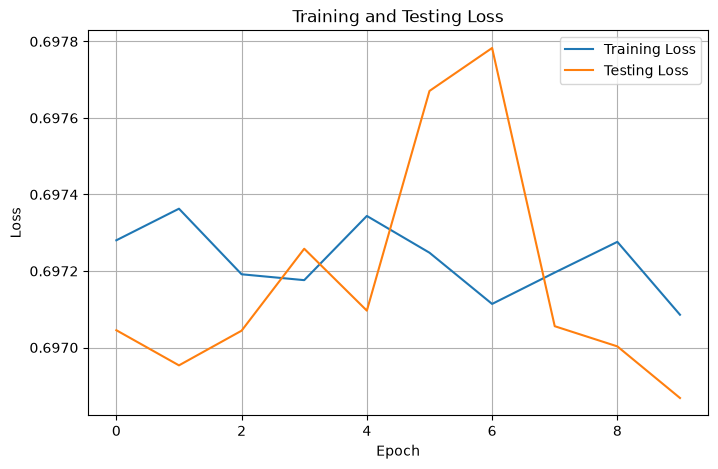

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Testing Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.grid(True)

In [11]:
t_query = np.array([[-0.2]], dtype=np.float32)

# Scale input
t_query_scaled = x_scaler.transform(t_query)

# Predict
y_pred_scaled = model.predict(t_query_scaled, verbose=0)

# Convert back to physical units
y_pred = y_scaler.inverse_transform(y_pred_scaled)

print('Prediction at t = -0.2')
print('n  =', y_pred[0,0])
print('C1 =', y_pred[0,1])
print('C2 =', y_pred[0,2])
print('C3 =', y_pred[0,3])
print('C4 =', y_pred[0,4])
print('C5 =', y_pred[0,5])
print('C6 =', y_pred[0,6])

Prediction at t = -0.2
n  = 0.99871385
C1 = 104.61281
C2 = 234.92827
C3 = 42.40342
C4 = 45.750526
C5 = 3.195989
C6 = 0.23484384


In [12]:
y_pred_scaled = model.predict(X_scaled, verbose=0)

# Convert back to physical units
y_pred_phys = y_scaler.inverse_transform(y_pred_scaled)
y_true_phys = y

epsilon = 1e-8

mape_per_col = np.mean(
    np.abs(
        (y_true_phys - y_pred_phys) /
        (np.abs(y_true_phys) + epsilon)
    ),
    axis=0
) * 100

overall_mape = np.mean(mape_per_col)

names = ['n','C1','C2','C3','C4','C5','C6']

print('\\nPer-variable error:')
for name, err in zip(names, mape_per_col):
    print(f'{name}: {err:.4f}%')

print(f'\\nOverall Prediction Error: {overall_mape:.4f}%')

if overall_mape < 2.0:
    print('SUCCESS: Error < 2%')
else:
    print('Need more training/tuning')

\nPer-variable error:
n: 0.1403%
C1: 0.1178%
C2: 0.1151%
C3: 0.1251%
C4: 0.1281%
C5: 0.1370%
C6: 0.1385%
\nOverall Prediction Error: 0.1288%
SUCCESS: Error < 2%


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 206us/step


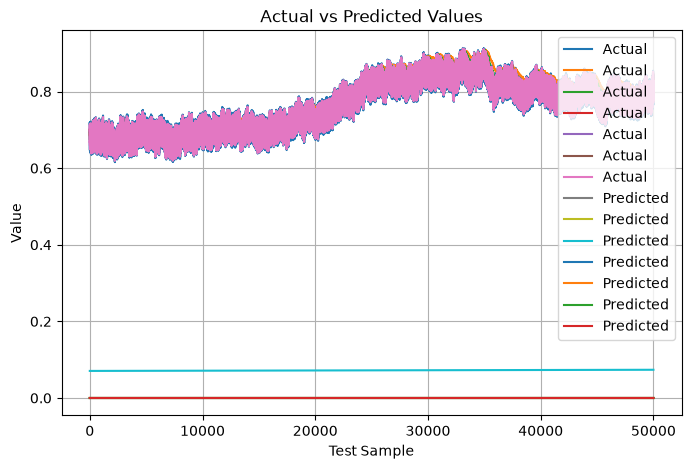

In [39]:
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(X_scaled)

# Plot actual vs predicted
plt.figure(figsize=(8, 5))

plt.plot(y_scaled, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.xlabel('Test Sample')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)

plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
EPOCHS = 5

for epoch in range(EPOCHS):

    print(f'\\n===== EPOCH {epoch+1}/{EPOCHS} =====')

    chunk_id = 0

    for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE):

        chunk_id += 1

        # Prepare chunk
        X_chunk = chunk[['time']].values.astype(np.float32)
        rho_chunk = chunk[['rho']].values.astype(np.float32)
        y_chunk = chunk[
            ['p','C1','C2','C3','C4','C5','C6']
        ].values.astype(np.float32)

        X_scaled = x_scaler.transform(X_chunk)
        rho_scaled = rho_scaler.transform(rho_chunk)
        y_scaled = y_scaler.transform(y_chunk)

        # Update global tensors used by mse_loss()
        x_train_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
        rho_train_tf = tf.convert_to_tensor(rho_scaled, dtype=tf.float32)
        y_train_tf = tf.convert_to_tensor(y_scaled, dtype=tf.float32)

        # Train on this chunk
        model.fit(
            X_scaled,
            y_scaled,
            epochs=1,
            batch_size=1024,
            verbose=0
        )

        print(f'Chunk {chunk_id} completed')

print('\\nTraining finished.')

\n===== EPOCH 1/5 =====
Chunk 1 completed
Chunk 2 completed
Chunk 3 completed
Chunk 4 completed
Chunk 5 completed
Chunk 6 completed
Chunk 7 completed
Chunk 8 completed
Chunk 9 completed
Chunk 10 completed
Chunk 11 completed
Chunk 12 completed
Chunk 13 completed
Chunk 14 completed
Chunk 15 completed
Chunk 16 completed
Chunk 17 completed
Chunk 18 completed
Chunk 19 completed
Chunk 20 completed
\n===== EPOCH 2/5 =====
Chunk 1 completed
Chunk 2 completed
Chunk 3 completed
Chunk 4 completed
Chunk 5 completed
Chunk 6 completed
Chunk 7 completed
Chunk 8 completed
Chunk 9 completed
Chunk 10 completed
Chunk 11 completed
Chunk 12 completed
Chunk 13 completed
Chunk 14 completed
Chunk 15 completed
Chunk 16 completed
Chunk 17 completed
Chunk 18 completed
Chunk 19 completed
Chunk 20 completed
\n===== EPOCH 3/5 =====
Chunk 1 completed
Chunk 2 completed
Chunk 3 completed
Chunk 4 completed
Chunk 5 completed
Chunk 6 completed
Chunk 7 completed
Chunk 8 completed
Chunk 9 completed
Chunk 10 completed
Chunk

In [14]:
epsilon = 1e-8

# Running totals
total_error = np.zeros(7, dtype=np.float64)
total_samples = 0

print('Evaluating model on all chunks...')

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE):

    # Extract
    X_chunk = chunk[['time']].values.astype(np.float32)

    y_chunk = chunk[
        ['p','C1','C2','C3','C4','C5','C6']
    ].values.astype(np.float32)

    # Scale input
    X_scaled = x_scaler.transform(X_chunk)

    # Predict
    y_pred_scaled = model.predict(X_scaled, verbose=0)

    # Convert back to physical units
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Percentage error
    error = np.abs(
        (y_pred - y_chunk) /
        (np.abs(y_chunk) + epsilon)
    ) * 100.0

    # Accumulate
    total_error += error.sum(axis=0)
    total_samples += len(y_chunk)

# Mean error per variable
mape_per_col = total_error / total_samples

# Overall error
overall_mape = np.mean(mape_per_col)

names = ['n','C1','C2','C3','C4','C5','C6']

print('\\n===== FINAL RESULTS =====')

for name, err in zip(names, mape_per_col):
    print(f'{name}: {err:.4f}%')

print(f'\\nOverall Prediction Error: {overall_mape:.4f}%')

if overall_mape < 2.0:
    print('SUCCESS: PINN achieved < 2% error')
else:
    print('Target not reached yet')

Evaluating model on all chunks...
\n===== FINAL RESULTS =====
n: 0.2052%
C1: 0.1830%
C2: 0.1676%
C3: 0.1901%
C4: 0.1930%
C5: 0.2019%
C6: 0.2034%
\nOverall Prediction Error: 0.1920%
SUCCESS: PINN achieved < 2% error


In [15]:
@tf.function
def compute_loss_debug(x_batch, y_batch, rho_batch):

    with tf.GradientTape(persistent=True) as tape:

        tape.watch(x_batch)

        y_pred_all = model(x_batch)

        n_pred_tf = y_pred_all[:, 0:1]

        c1_pred_tf = y_pred_all[:, 1:2]
        c2_pred_tf = y_pred_all[:, 2:3]
        c3_pred_tf = y_pred_all[:, 3:4]
        c4_pred_tf = y_pred_all[:, 4:5]
        c5_pred_tf = y_pred_all[:, 5:6]
        c6_pred_tf = y_pred_all[:, 6:7]

    # Derivatives
    dn_dt = tape.gradient(n_pred_tf, x_batch)

    dc1_dt = tape.gradient(c1_pred_tf, x_batch)
    dc2_dt = tape.gradient(c2_pred_tf, x_batch)
    dc3_dt = tape.gradient(c3_pred_tf, x_batch)
    dc4_dt = tape.gradient(c4_pred_tf, x_batch)
    dc5_dt = tape.gradient(c5_pred_tf, x_batch)
    dc6_dt = tape.gradient(c6_pred_tf, x_batch)

    del tape

    # ---------------- DATA LOSS ----------------
    loss_n = tf.reduce_mean(
        tf.square(n_pred_tf - y_batch[:, 0:1])
    )

    loss_data1 = tf.reduce_mean(
        tf.square(c1_pred_tf - y_batch[:, 1:2])
    )

    loss_data2 = tf.reduce_mean(
        tf.square(c2_pred_tf - y_batch[:, 2:3])
    )

    loss_data3 = tf.reduce_mean(
        tf.square(c3_pred_tf - y_batch[:, 3:4])
    )

    loss_data4 = tf.reduce_mean(
        tf.square(c4_pred_tf - y_batch[:, 4:5])
    )

    loss_data5 = tf.reduce_mean(
        tf.square(c5_pred_tf - y_batch[:, 5:6])
    )

    loss_data6 = tf.reduce_mean(
        tf.square(c6_pred_tf - y_batch[:, 6:7])
    )

    loss_data = (
        loss_n + loss_data1 + loss_data2 +
        loss_data3 + loss_data4 +
        loss_data5 + loss_data6
    )

    # ---------------- BC LOSS ----------------
    t_totest_tf = tf.constant([[-0.2]], dtype=tf.float32)

    y_zero = model(t_totest_tf)

    loss_bc = tf.reduce_sum(y_zero)

    # ---------------- PHYSICS LOSS ----------------
    sum_lambda_C = (
        lambda_C[0] * c1_pred_tf +
        lambda_C[1] * c2_pred_tf +
        lambda_C[2] * c3_pred_tf +
        lambda_C[3] * c4_pred_tf +
        lambda_C[4] * c5_pred_tf +
        lambda_C[5] * c6_pred_tf
    )

    ff_n = dn_dt - (
        ((rho_batch - beta_tf) / ngen_tf) * n_pred_tf
        + sum_lambda_C
    )

    f_c1 = dc1_dt - (
        (beta_i[0] / ngen) * n_pred_tf
        - lambda_C[0] * c1_pred_tf
    )

    f_c2 = dc2_dt - (
        (beta_i[1] / ngen) * n_pred_tf
        - lambda_C[1] * c2_pred_tf
    )

    f_c3 = dc3_dt - (
        (beta_i[2] / ngen) * n_pred_tf
        - lambda_C[2] * c3_pred_tf
    )

    f_c4 = dc4_dt - (
        (beta_i[3] / ngen) * n_pred_tf
        - lambda_C[3] * c4_pred_tf
    )

    f_c5 = dc5_dt - (
        (beta_i[4] / ngen) * n_pred_tf
        - lambda_C[4] * c5_pred_tf
    )

    f_c6 = dc6_dt - (
        (beta_i[5] / ngen) * n_pred_tf
        - lambda_C[5] * c6_pred_tf
    )

    f_c = (
        f_c1 + f_c2 + f_c3 +
        f_c4 + f_c5 + f_c6
    )

    loss_physics = (
        tf.reduce_mean(tf.square(ff_n)) +
        tf.reduce_mean(tf.square(f_c))
    )

    total_loss = (
        loss_data +
        loss_bc +
        loss_physics
    )

    return total_loss, loss_data, loss_bc, loss_physics

In [16]:
total_loss, l_data, l_bc, l_phys = compute_loss_debug(
    x_train_tf,
    y_train_tf,
    rho_train_tf
)

print('Data Loss     :', float(l_data))
print('Boundary Loss :', float(l_bc))
print('Physics Loss  :', float(l_phys))
print('Total Loss    :', float(total_loss))

Data Loss     : 4.129449844360352
Boundary Loss : 0.002176315523684025
Physics Loss  : 0.0039625512436032295
Total Loss    : 4.135588645935059


In [17]:
epsilon = 1e-8

total_error = np.zeros(7, dtype=np.float64)
total_samples = 0

print('Evaluating model on all chunks...')

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE):

    X_chunk = chunk[['time']].values.astype(np.float32)

    y_chunk = chunk[
        ['p','C1','C2','C3','C4','C5','C6']
    ].values.astype(np.float32)

    X_scaled = x_scaler.transform(X_chunk)

    y_pred_scaled = model.predict(X_scaled, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    error = np.abs(
        (y_pred - y_chunk) /
        (np.abs(y_chunk) + epsilon)
    ) * 100.0

    total_error += error.sum(axis=0)
    total_samples += len(y_chunk)

mape_per_col = total_error / total_samples
overall_mape = np.mean(mape_per_col)

names = ['n','C1','C2','C3','C4','C5','C6']

print('\\n===== FINAL RESULTS =====')

for name, err in zip(names, mape_per_col):
    print(f'{name}: {err:.4f}%')

print(f'\\nOverall Prediction Error: {overall_mape:.4f}%')

Evaluating model on all chunks...
\n===== FINAL RESULTS =====
n: 0.2052%
C1: 0.1830%
C2: 0.1676%
C3: 0.1901%
C4: 0.1930%
C5: 0.2019%
C6: 0.2034%
\nOverall Prediction Error: 0.1920%


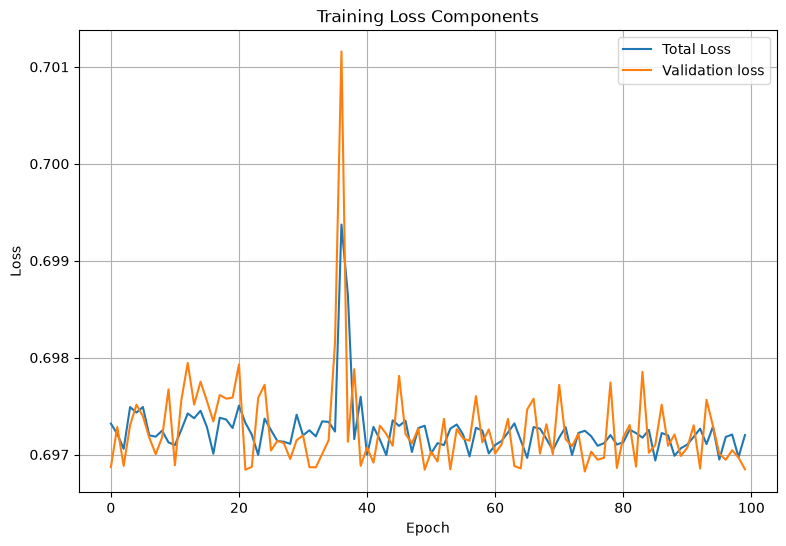

In [37]:
plt.figure(figsize=(9, 6))

plt.plot(history.history['loss'], label='Total Loss')
plt.plot(history.history['val_loss'],label = 'Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Components')
plt.legend()
plt.grid(True)

plt.savefig('training_loss_components.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
history = model.fit(
    X_scaled,
    y_scaled,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - loss: 0.6973 - mean_absolute_error: 0.7580 - val_loss: 0.6969 - val_mean_absolute_error: 0.7930
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - loss: 0.6972 - mean_absolute_error: 0.7579 - val_loss: 0.6973 - val_mean_absolute_error: 0.7931
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - loss: 0.6971 - mean_absolute_error: 0.7579 - val_loss: 0.6969 - val_mean_absolute_error: 0.7931
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - loss: 0.6975 - mean_absolute_error: 0.7580 - val_loss: 0.6973 - val_mean_absolute_error: 0.7930
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - loss: 0.6974 - mean_absolute_error: 0.7580 - val_loss: 0.6975 - val_mean_absolute_error: 0.7930
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - loss: 0.6975 - mean_absolute_error: 0.7580 - val_loss: 0.6974 - val_mean_absolute_error: 0.7929
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - loss: 0.6972 - mean_absolute_error: 0.7

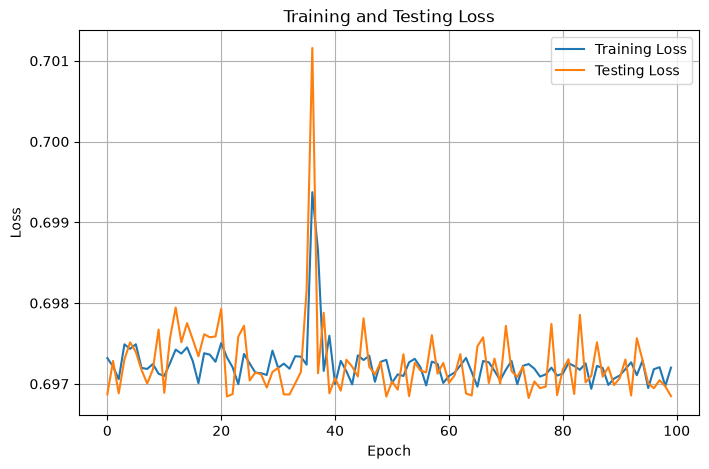

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Testing Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.grid(True)

plt.savefig('training_testing_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
print(history.history.keys())

dict_keys(['loss', 'mean_absolute_error'])


In [20]:
model.save('pfbr_pinn_model.keras')
print('Keras model saved.')

Keras model saved.


In [21]:
model.export('pfbr_savedmodel')
print('SavedModel exported.')

INFO:tensorflow:Assets written to: pfbr_savedmodel/assets


INFO:tensorflow:Assets written to: pfbr_savedmodel/assets


Saved artifact at 'pfbr_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  5270905168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5270905936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5270907280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5270906896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5270906128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5270908048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5270908240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5270907856: TensorSpec(shape=(), dtype=tf.resource, name=None)
SavedModel exported.


In [22]:
loaded_model = tf.keras.models.load_model('pfbr_pinn_model.keras')

print('Model loaded successfully.')
loaded_model.summary()

TypeError: Expected 'config' to be a dict for Function,
instead got <class 'str'>
Full config: {'module': 'tensorflow.python.eager.polymorphic_function.polymorphic_function', 'class_name': 'Function', 'config': 'loss', 'registered_name': 'Function'}

In [23]:
loaded_model = tf.keras.models.load_model(
    'pfbr_pinn_model.keras',
    compile=False
)

print('Model loaded successfully!')
loaded_model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,903 (34.78 KB)

 Trainable params: 8,903 (34.78 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
t_query = np.array([[-0.2]], dtype=np.float32)

t_query_scaled = x_scaler.transform(t_query)

pred1 = model.predict(t_query_scaled, verbose=0)
pred2 = loaded_model.predict(t_query_scaled, verbose=0)

print('Max difference:',
      np.max(np.abs(pred1 - pred2)))

Max difference: 0.0
